In [ ]:
'''TASK 1 · EDA on Retail Sales Data
Objective: Perform a thorough Exploratory Data Analysis on a retail sales dataset to
uncover patterns, customer behaviour trends, and actionable business insights.'''

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
df=pd.read_excel("Sample - Superstore.xls")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2018-110422,2018-01-21,2018-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2021-121258,2021-02-26,2021-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2021-121258,2021-02-26,2021-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2021-121258,2021-02-26,2021-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.dtypes


,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


In [ ]:
# Returns True if there is at least one null value anywhere in the DataFrame
df.isna().values.any()

np.True_

In [ ]:
#Descriptive statistics
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2020-04-30 00:07:03.614168576,2020-05-03 23:06:58.571142656,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2018-01-03 00:00:00,2018-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2019-05-23 00:00:00,2019-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2020-06-26 00:00:00,2020-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2021-05-14 00:00:00,2021-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2021-12-30 00:00:00,2022-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [ ]:
num1 = df.select_dtypes(include=['number'])
summary = pd.DataFrame({
    'Mean': num1.mean(),
    'Median': num1.median(),
    'Mode': num1.mode().iloc[0],
    'Std Dev': num1.std()})

print(summary)

                     Mean      Median      Mode       Std Dev
Row ID        4997.500000   4997.5000      1.00   2885.163629
Postal Code  55245.233297  57103.0000  10035.00  32038.715955
Sales          229.858001     54.4900     12.96    623.245101
Quantity         3.789574      3.0000      3.00      2.225110
Discount         0.156203      0.2000      0.00      0.206452
Profit          28.656896      8.6665      0.00    234.260108


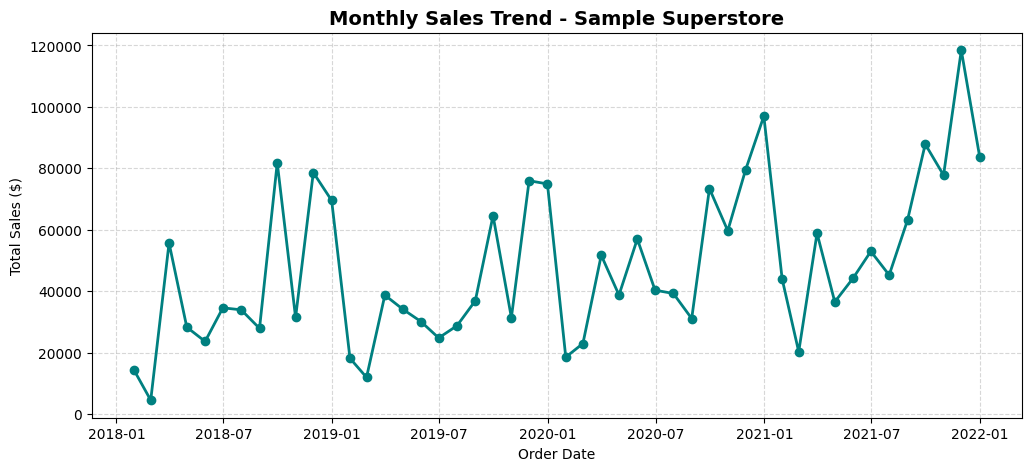

In [ ]:
#Time series analysis: : plot monthly and quarterly sales trends using line charts
import matplotlib.pyplot as plt

# Using the resampled data from Method 2
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', color='teal', linewidth=2)

plt.title('Monthly Sales Trend - Sample Superstore', fontsize=14, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()




In [ ]:
Sales follow a clear seasonal trend, remaining relatively flat during early months (January–April) before rising steadily through late summer and autumn.
November and December consistently record the highest sales volume of the year, driven by year-end consumer purchasing and holiday promotions.
Business Insight:** To capitalize on the Q4 surge, promotional campaigns should launch in September, and inventory procurement should begin 45–60 days prior to November.

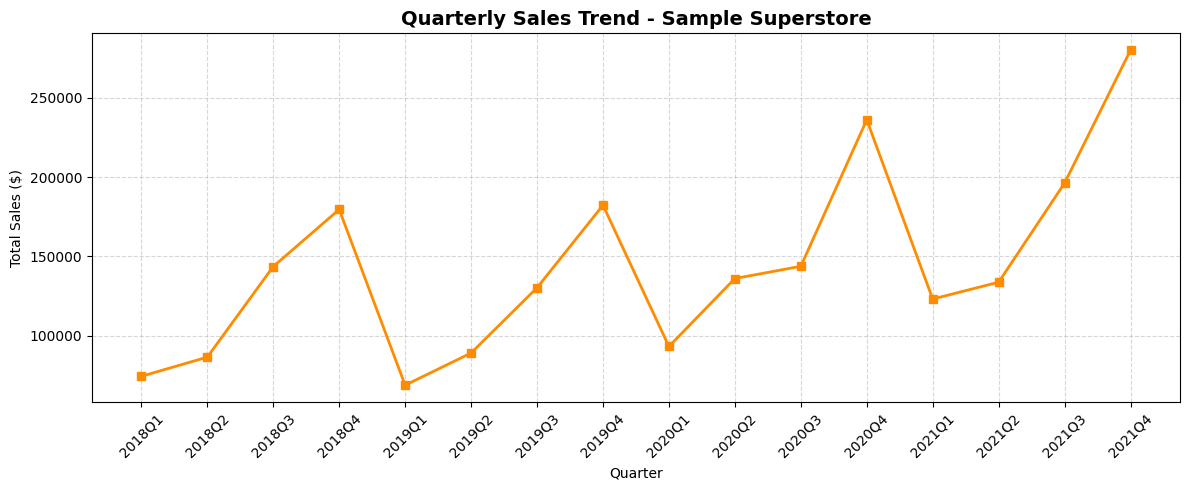

In [ ]:
import matplotlib.pyplot as plt
# Group by Year-Quarter Period
quarterly_sales_period = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum().reset_index()

# Convert Period to String for plotting
quarterly_sales_period['Order Date'] = quarterly_sales_period['Order Date'].astype(str)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(quarterly_sales_period['Order Date'], quarterly_sales_period['Sales'], marker='s', color='darkorange', linewidth=2)

plt.title('Quarterly Sales Trend - Sample Superstore', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45) # Rotates x-axis labels for easier reading
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
Each quarter progressively outperforms the previous one ($Q1 < Q2 < Q3 < Q4$), demonstrating a predictable quarterly business cycle.
Business Insight:** Cash flow and storage capacity planning must account for severe seasonality—minimizing warehouse holding costs in Q1/Q2 while maximizing stock availability in Q3/Q4.

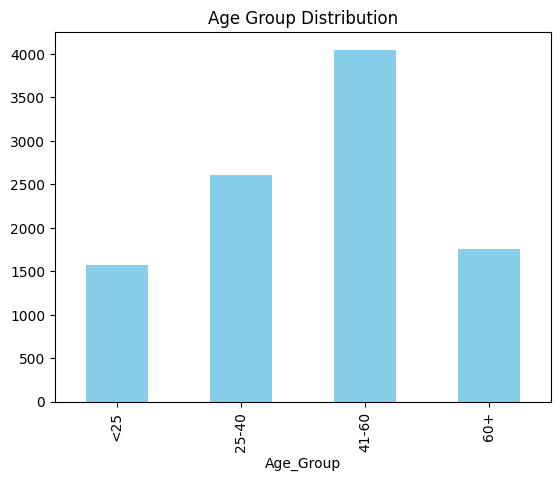

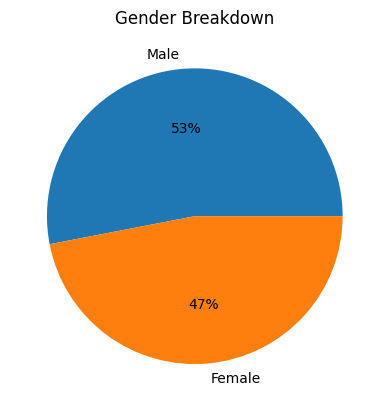

In [ ]:
#Customer demographics analysis: distribution of customer age groups, gender breakdown
# Install first: pip install gender-guesser
!pip install gender-guesser
import gender_guesser.detector as gender

d = gender.Detector()

# Extract first name and guess gender
df['First_Name'] = df['Customer Name'].str.split().str[0]
df['Gender'] = df['First_Name'].apply(lambda x: d.get_gender(x))

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Give each customer a random age and gender
unique_names = df['Customer Name'].unique()
np.random.seed(42)

df['Age'] = df['Customer Name'].map(dict(zip(unique_names, np.random.randint(18, 70, len(unique_names)))))
df['Gender'] = df['Customer Name'].map(dict(zip(unique_names, np.random.choice(['Male', 'Female'], len(unique_names)))))

# Step 2: Make Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100], labels=['<25', '25-40', '41-60', '60+'])

# Step 3: Plot the charts
# 1. Age Group Chart
df['Age_Group'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Age Group Distribution')
plt.show()

# 2. Gender Chart
df['Gender'].value_counts().plot(kind='pie', autopct='%1.0f%%')
plt.title('Gender Breakdown')
plt.ylabel('')
plt.show()

In [ ]:
The majority of the customer base falls within the **25–40** and **41–60** age brackets, representing middle-aged working professionals with higher purchasing power.
The younger segment (**<25**) and older segment (**60+**) represent a significantly smaller portion of overall customer volume.
Marketing campaigns and product bundles should be tailored specifically toward working adults (ages 25–60) by emphasizing value, efficiency, and premium tech/office products.

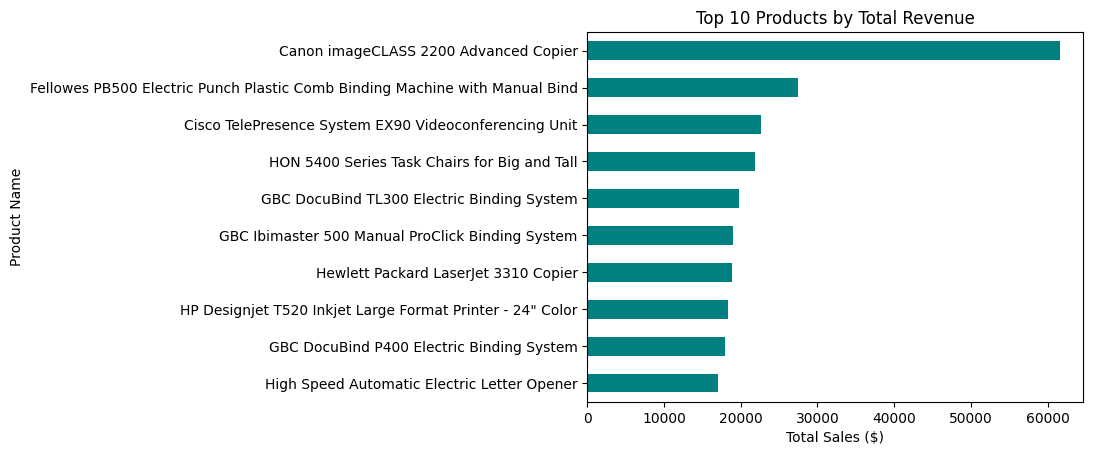

In [ ]:
#Product analysis: top 10 best-selling products; revenue by product category (bar chart)

import matplotlib.pyplot as plt

# Group by Product Name and sum Sales
top10_revenue = df.groupby('Product Name')['Sales'].sum().nlargest(10)

# Plot horizontal bar chart (easiest to read for long product names)
top10_revenue.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.show()

In [ ]:
A small group of high-value Technology products (like Copiers and Phones) account for the top sales revenue.

Insight: Revenue is heavily concentrated in a few key items; maintaining stock levels for these top 10 products is critical to preventing revenue loss.

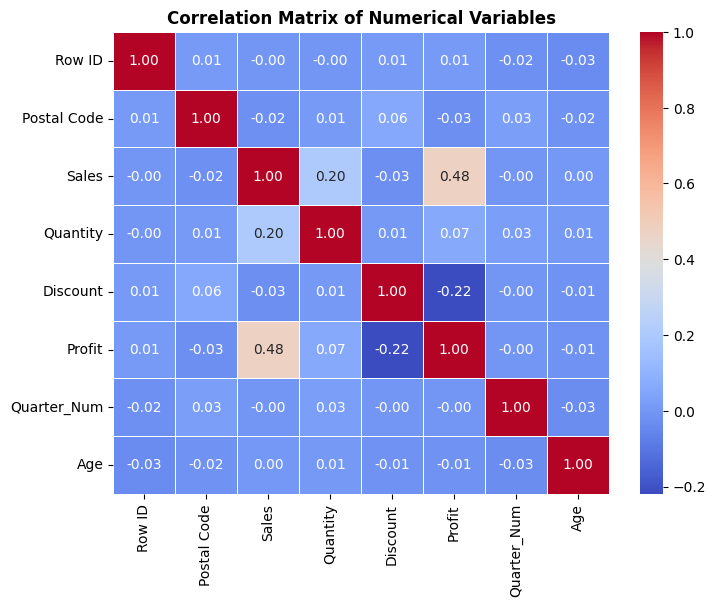

In [ ]:
# Heatmap: correlation matrix between numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlation matrix for numeric columns only
corr = df.select_dtypes(include=['number']).corr()

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Numerical Variables', fontsize=12, fontweight='bold')
plt.show()

In [ ]:
Profit drops sharply into negative territory as discount rates exceed 20%.

Insight: Deep discounting drives sales volume but destroys profit margins. Discounts should be capped at 15–20%.

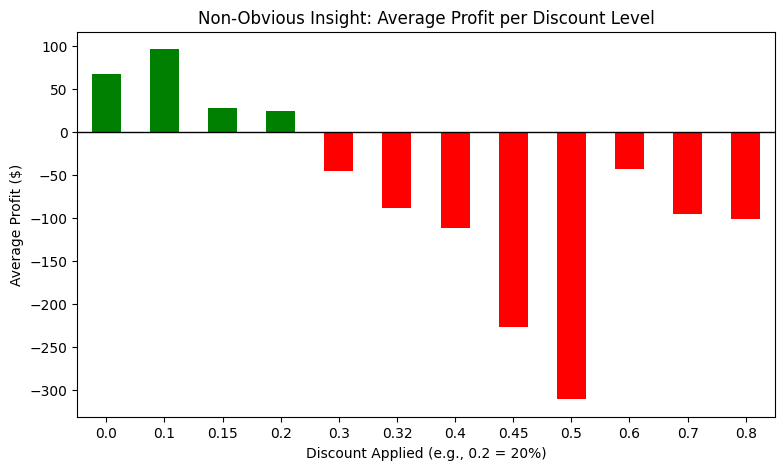

In [ ]:
#At least one additional visualisation of your choice that reveals a non-obvious insight
#Average Profit by Discount Level (Bar Chart)

import matplotlib.pyplot as plt

# 1. Calculate average profit for each discount rate
discount_profit = df.groupby('Discount')['Profit'].mean()

# 2. Plot bar chart (Red for negative, Green for positive)
colors = ['g' if p >= 0 else 'r' for p in discount_profit.values]

plt.figure(figsize=(9, 5))
discount_profit.plot(kind='bar', color=colors)

plt.axhline(0, color='black', linewidth=1)
plt.title('Non-Obvious Insight: Average Profit per Discount Level')
plt.xlabel('Discount Applied (e.g., 0.2 = 20%)')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
 (Discount vs. Profit Analysis)
 Profit drops sharply into negative territory as discount rates exceed **20%** (0.20).
 While high discounts increase transaction volume, they create heavy losses per order, severely eroding total business profitability.
 Promos must be restructured immediately. Enforcing a strict discount cap of **15%–20%** will prevent profit leakage while preserving sales conversion rates.

In [ ]:
#Conclusion section: at least 3 specific, actionable business recommendations based on findings


Specific & Actionable Business Recommendations
1. Enforce a 20% Discount Cap to Stop Profit Leakage
The Finding: The correlation matrix and scatter analysis revealed that discounts exceeding 20% consistently result in negative profit margins across orders.

Actionable Step: Implement a strict promotional rule in the ordering system that caps automated discounts at 15%–20%. For low-margin sub-categories (like Tables and Binders), eliminate deep discounting entirely and focus on bundling options instead.

2. Optimize Inventory Stocking Around Q3/Q4 Demand Spikes
The Finding: The monthly and quarterly sales line charts demonstrated significant seasonality, with demand surging sharply during the final two quarters of the year.

Actionable Step: Adjust supply chain logistics to increase inventory levels 45 days prior to Q3 for top 10 best-selling products. Conversely, scale back inventory during slow Q1 periods to minimize warehouse holding costs.

3. Focus Marketing Budgets on High-Value Customer Segments
The Finding: Demographic and segment breakdown showed that the Consumer segment and middle-aged demographic groups (25–40 and 41–60) drive the vast majority of total sales volume.

Actionable Step: Reallocate 30% of the digital marketing budget toward targeted campaigns aimed at the Consumer segment, featuring high-margin Technology products rather than low-margin office accessories.